# HEAL-BOT PRO


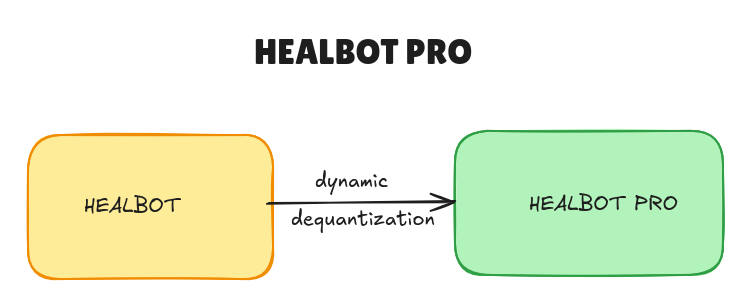

## Step 1: Installing and importing the libraries

In [ ]:
!pip install -q accelerate peft bitsandbytes transformers trl
# !pip uninstall accelerate peft bitsandbytes transformers trl -y
# !pip install accelerate peft bitsandbytes transformers trl

In [ ]:
!pip show accelerate
!pip show bitsandbytes
!pip show transformers
!pip show trl

In [ ]:
!pip install huggingface_hub

In [ ]:
!nvcc --version

In [ ]:
import torch
print(torch.cuda.is_available())
print(torch.version.cuda)

In [ ]:
import bitsandbytes
print(bitsandbytes.__version__)

In [ ]:
import torch
from trl import SFTTrainer
from peft import LoraConfig
from datasets import load_dataset
from transformers import (AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, TrainingArguments, pipeline)

## Step 2: Loading the model

In [ ]:
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16, # Changed to bfloat16
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True
)
llama_model = AutoModelForCausalLM.from_pretrained(
    "aboonaji/llama2finetune-v2",
    quantization_config=quantization_config,
    device_map="auto",
    torch_dtype=torch.bfloat16 # Changed to bfloat16
)
llama_model.config.use_cache = False
print(f"Model Memory: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")

In [ ]:
import torch
print(torch.cuda.memory_allocated() / 1024**3, "GB")  # Memory in GB

In [ ]:
# Check memory and quantization
print(f"GPU Memory Allocated: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
print(f"Parameter dtype: {next(llama_model.parameters()).dtype}")
for name, param in llama_model.named_parameters():
    print(f"{name}: {param.dtype}")
    break  # Just check the first parameter

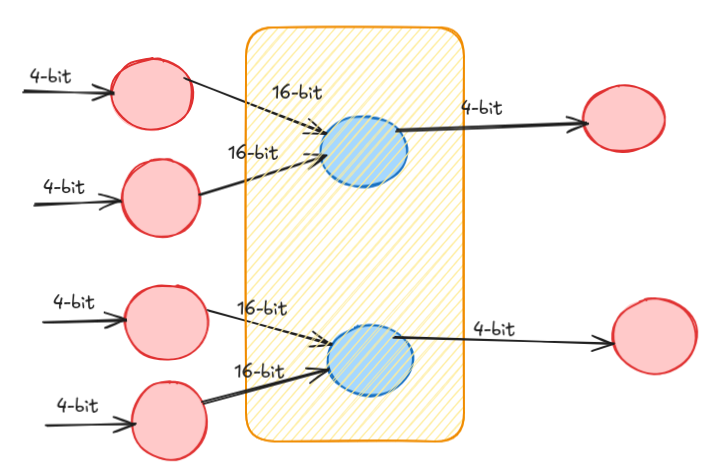

## Step 3: Loading the tokenizer

In [ ]:
llama_tokenizer = AutoTokenizer.from_pretrained(pretrained_model_name_or_path = "aboonaji/llama2finetune-v2", trust_remote_code = True)
llama_tokenizer.pad_token = llama_tokenizer.eos_token
llama_tokenizer.padding_side = "right"

llama_tokenizer_dir = "llama-tokenizer"
llama_tokenizer.save_pretrained(llama_tokenizer_dir)

## Step 4: Setting the training arguments

In [ ]:
# training_arguments = TrainingArguments(output_dir = "./results", per_device_train_batch_size = 2, max_steps = 50)

In [ ]:
training_arguments = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=1,
    gradient_accumulation_steps=4,
    max_steps=50,
    gradient_checkpointing=True,
    fp16=False, # Set to False
    bf16=True,  # Added bfloat16 support
    learning_rate=2e-5,
    logging_steps=10,
    save_steps=25,
    optim="adamw_torch"
)

Model processes a single batch (batch_size=1) → Saves memory.

After 4 steps (gradient_accumulation_steps=4), gradients are applied → Simulates a batch size of 4.

After every 10 steps, logs training progress → Keeps track of learning.

After every 25 steps, saves a checkpoint → Allows resuming training later.

After 50 steps, training stops → Useful for quick experimentation.

## Step 5: Creating the Supervised Fine-Tuning trainer

In [ ]:
# llama_sft_trainer = SFTTrainer(model = llama_model,
#                                args = training_arguments,
#                                train_dataset = load_dataset(path = "aboonaji/wiki_medical_terms_llam2_format", split = "train"),
#                                tokenizer = llama_tokenizer,
#                                peft_config = LoraConfig(task_type = "CAUSAL_LM", r = 64, lora_alpha = 16, lora_dropout = 0.1),
#                                dataset_text_field = "text")

In [ ]:
import torch
print(torch.cuda.memory_allocated() / 1024**3, "GB")  # Memory in GB

In [ ]:
# def tokenize_function(example):
#     return llama_tokenizer(example["text"], truncation=True, padding="max_length", max_length=128)
# tokenized_dataset = load_dataset("aboonaji/wiki_medical_terms_llam2_format", split="train").map(tokenize_function, batched=True)

In [ ]:
llama_sft_trainer = SFTTrainer(
    model=llama_model,
    args=training_arguments,
    train_dataset=load_dataset(path="aboonaji/wiki_medical_terms_llam2_format", split="train"),
    peft_config=LoraConfig(task_type="CAUSAL_LM", r=64, lora_alpha=16, lora_dropout=0.1)
)

## Step 6: Training the model

In [ ]:
!pip install wandb

In [ ]:
wandb login

In [ ]:
llama_sft_trainer.train()

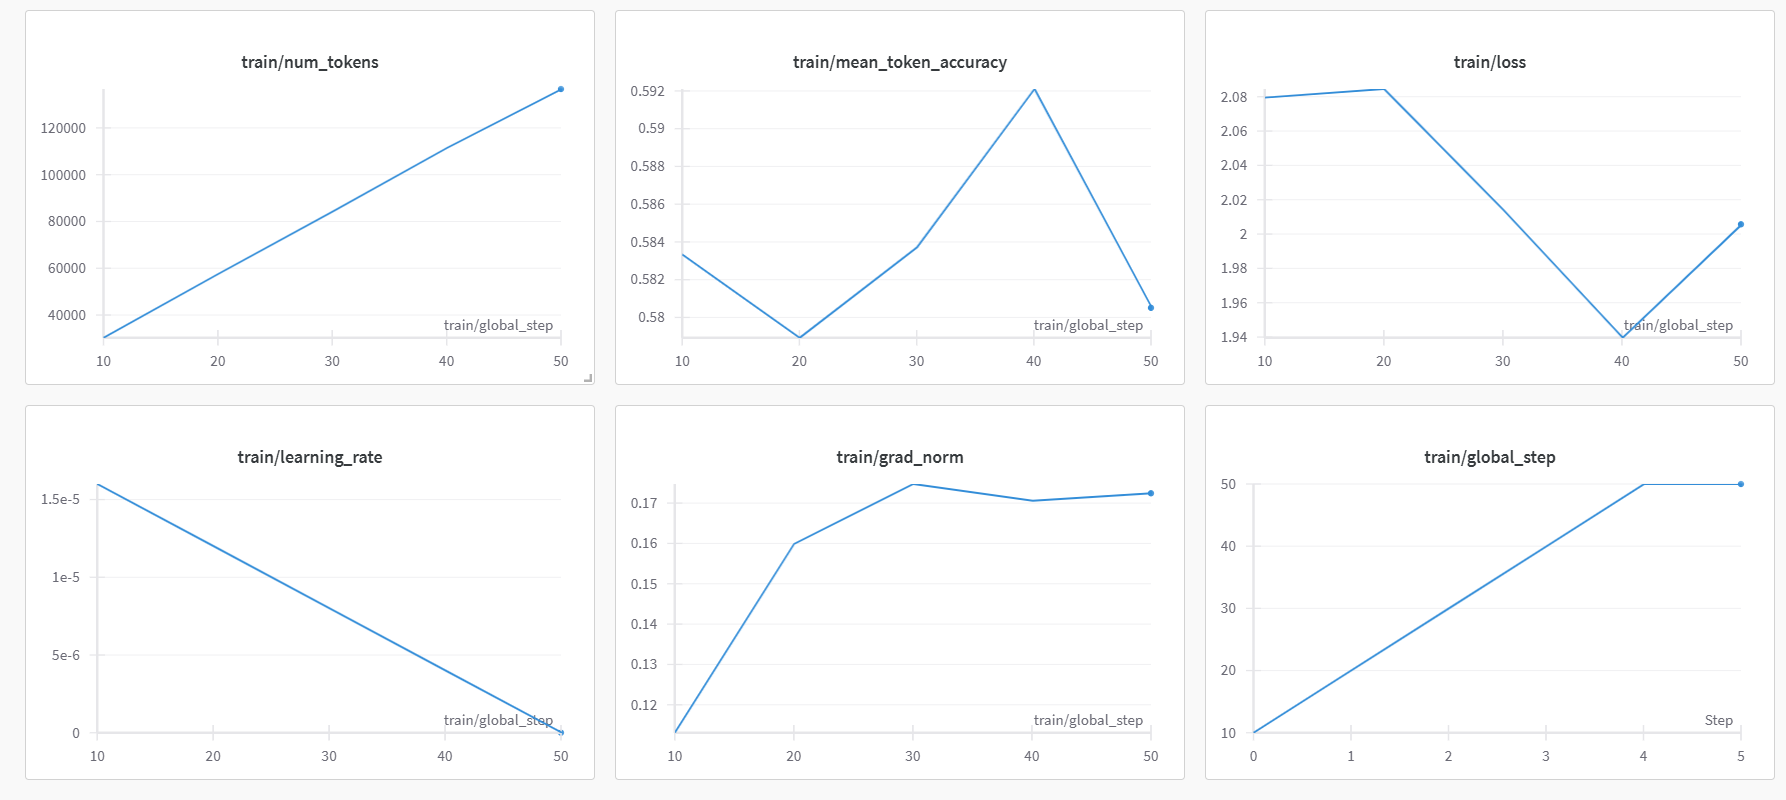

## Step 7: Chatting with the model

In [ ]:
from peft import PeftModel
from transformers import pipeline

# 1. Load BASE + your LoRA adapter (from training checkpoint)
checkpoint_path = "./results/checkpoint-50"  # <-- your last checkpoint

model = PeftModel.from_pretrained(llama_model, checkpoint_path)
model.eval()  # inference mode

In [ ]:
# 2. Correct Llama2 chat format
user_prompt = "Please tell me about Ascariasis"

prompt = f"<s>[INST] <<SYS>>\nYou are HealBot Pro, a helpful medical assistant. Answer accurately and briefly.When disease is given mention the symptoms and when symptoms are given map it to give correspondingly possible diseases\n<</SYS>>\n\n{user_prompt} [/INST]"

# 3. Test pipeline
pipe = pipeline(
    "text-generation",
    model=model,
    tokenizer=llama_tokenizer,  # your trained tokenizer
    max_new_tokens=256,   # better than max_length
    temperature=0.1,      # low for coherent medical answers
    do_sample=True,
    pad_token_id=llama_tokenizer.eos_token_id
)

result = pipe(prompt)
print("✅ HealBot Pro:", result[0]['generated_text'].split("[/INST]")[-1].strip())

In [ ]:
# 2. Correct Llama2 chat format
user_prompt = "Symptoms include swelling and lack of breathe"

prompt = f"<s>[INST] <<SYS>>\nYou are HealBot Pro, a helpful medical assistant. Answer accurately and briefly. When disease is given mention the symptoms and when symptoms are given map it to give correspondingly possible diseases\n<</SYS>>\n\n{user_prompt} [/INST]"

# 3. Test pipeline
pipe = pipeline(
    "text-generation",
    model=model,
    tokenizer=llama_tokenizer,  # your trained tokenizer
    max_new_tokens=256,   # better than max_length
    temperature=0.1,      # low for coherent medical answers
    do_sample=True,
    pad_token_id=llama_tokenizer.eos_token_id
)

result = pipe(prompt)
print("✅ HealBot Pro:", result[0]['generated_text'].split("[/INST]")[-1].strip())

In [ ]:
# 2. Correct Llama2 chat format
user_prompt = "How is the weather today?"

prompt = f"<s>[INST] <<SYS>>\nYou are HealBot Pro, a helpful medical assistant. Answer accurately and briefly.When disease is given mention the symptoms and when symptoms are given map it to give correspondingly possible diseases. Kindly avoid answering questions that are not suitable for your role\n<</SYS>>\n\n{user_prompt} [/INST]"

# 3. Test pipeline
pipe = pipeline(
    "text-generation",
    model=model,
    tokenizer=llama_tokenizer,  # your trained tokenizer
    max_new_tokens=256,   # better than max_length
    temperature=0.1,      # low for coherent medical answers
    do_sample=True,
    pad_token_id=llama_tokenizer.eos_token_id
)

result = pipe(prompt)
print("✅ HealBot Pro:", result[0]['generated_text'].split("[/INST]")[-1].strip())

**CONCLUSION**



1.   Quantization (Space Optimization)
2.   Dynamic Dequantization (Accuracy Optimization)
3.   Accelerate (Hardware Efficiency Automation)





In [ ]:
from datasets import load_dataset

# Store the location (dataset name) in a variable
dataset_name = "aboonaji/wiki_medical_terms_llam2_format"

# Load the dataset using the variable
training_data = load_dataset(dataset_name, split="train")

In [ ]:
training_data[:]

In [ ]:
!pip install neo4j thefuzz

In [ ]:
import pandas as pd
from neo4j import GraphDatabase
from thefuzz import process

In [ ]:
# --- 2. NEO4J CONNECTION ---
NEO4J_URI = "xxx"
NEO4J_USER = "neo4j"
NEO4J_PASSWORD = "xxxx"
driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))

In [ ]:
import json
from thefuzz import process 

def classify_entities_with_llm(text):
    global pipe
    sys_prompt = "<<SYS>> You are a medical entity extractor. Extract the primary disease and its symptoms from the text. IMPORTANT: Extract ONLY concise, formal medical names (1-3 words maximum). Do NOT output full sentences, descriptive text, or definitions. Return ONLY a valid JSON object with keys 'Disease' (string) and 'Symptoms' (list of short strings). <</SYS>>"
    prompt = f"<s> [INST] {sys_prompt} Text: {text} [/INST]"

    try:
        result = pipe(prompt)
        raw_output = result[0]['generated_text'].replace(prompt, "").strip()
        entities = json.loads(raw_output)
        return entities.get("Disease", ""), entities.get("Symptoms", [])
    except Exception as e:
        print(f"⚠️ Failed to parse LLM output as JSON: {e}")
        return None, []

def get_causes_from_local_llm(disease_name):
    global pipe
    sys_prompt = "<<SYS>> You are a helpful medical expert. Your answers should be concise and strictly follow instructions. <</SYS>>"
    instruction = f"List the primary medical causes or antecedents for the disease '{disease_name}'. Return ONLY a comma-separated list of short disease names. Do not include explanations."
    prompt = f"<s> [INST] {sys_prompt} {instruction} [/INST]"

    result = pipe(prompt)
    raw_output = result[0]['generated_text'].replace(prompt, "").strip()

    if "." in raw_output and "," not in raw_output:
        return [raw_output.strip('.')]
    return [x.strip() for x in raw_output.split(',')]

def build_knowledge_graph(dataset):
    df = dataset.to_pandas() if hasattr(dataset, 'to_pandas') else dataset
    
    graph_memory = []

    with driver.session() as session:
        
        print("--- Pass 1: Intelligently Extracting and Pushing Empty Nodes ---")
        for index, row in df.iterrows():
            raw_text = row['text']
            
            disease_name, symptoms_list = classify_entities_with_llm(raw_text)
            
            if not disease_name:
                continue
                
            graph_memory.append({
                "disease": disease_name.strip(),
                "symptoms": [s.strip() for s in symptoms_list]
            })

            session.run("MERGE (d:Disease {name: $name})", name=disease_name.strip())
            
            for symptom in symptoms_list:
                session.run("MERGE (s:Symptom {name: $name})", name=symptom.strip())
                
        print(f"✅ Pass 1 Complete. Processed {len(graph_memory)} base disease entities.")

        print("--- Pass 2: Populating Relationships Between Existing Nodes ---")
        
        valid_diseases_query = session.run("MATCH (d:Disease) RETURN d.name as name")
        all_valid_diseases = [record["name"] for record in valid_diseases_query]

        for item in graph_memory:
            disease = item["disease"]
            symptoms = item["symptoms"]
            
            print(f"🧠 Mapping Edges for: {disease}")

            for symptom in symptoms:
                session.run("""
                    MATCH (d:Disease {name: $d_name})
                    MATCH (s:Symptom {name: $s_name})
                    MERGE (d)-[:HAS_SYMPTOM]->(s)
                """, d_name=disease, s_name=symptom)

            try:
                suggested_causes = get_causes_from_local_llm(disease)

                for cause in suggested_causes:
                    match, score = process.extractOne(cause, all_valid_diseases)

                    if score > 85:
                        session.run("""
                            MATCH (cause_node:Disease {name: $cause})
                            MATCH (effect_node:Disease {name: $effect})
                            MERGE (effect_node)-[:CAUSED_BY]->(cause_node)
                        """, cause=match, effect=disease)
                        print(f"   🔗 Causal Link: [{disease}] -[:CAUSED_BY]-> [{match}]")
                        
            except Exception as e:
                print(f"   ❌ Error processing causes for {disease}: {e}")
                continue

if __name__ == "__main__":
    build_knowledge_graph(training_data)
    print("🚀 Knowledge Graph Construction Complete!")